<a href="https://colab.research.google.com/github/tacinunesc/Aula_1_Gemeos_Digitais_UniFacens/blob/main/aula2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning na Prática**

# **Importando as bibliotecas**

In [27]:
import matplotlib.dates as mdates  # Ferramentas para converter e formatar datas nos eixos do gráfico

import matplotlib.pyplot as plt    # Interface principal para criação de gráficos e figuras
import itertools                   # Funções para iterações eficientes (ex: combinações, ciclos)
# import matplotlib.pyplot as plt  <-- (Dica: você importou isso duas vezes, pode remover uma)

import pandas as pd                # Estruturas de dados (DataFrames) para manipulação e análise
import seaborn as sns              # Visualização de dados estatísticos baseada no Matplotlib
import warnings                    # Gerenciamento de alertas (ex: para ignorar avisos de depreciação)
import os                          # Interação com o sistema operacional (manipulação de caminhos e pastas)

import datetime                    # Manipulação de objetos de data e hora nativos do Python
import numpy as np                 # Operações matemáticas e suporte a arrays/matrizes

# Inserção do Dados


Vamos utilizar dados da Magalu para análisar com séries temporais, no período entre 1° de abrilde 2022 até 1° de abril de 2025

In [31]:
import yfinance as yf

# Defina o ticker do ativo
ticker = 'MGLU3.SA'

# Baixe os dados históricos
df = yf.download(ticker, start='2022-04-01', end='2025-04-01')

# Visualizando os dados
print(df)


/tmp/ipykernel_25828/652465138.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2022-04-01', end='2025-04-01')
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker       MGLU3.SA   MGLU3.SA   MGLU3.SA   MGLU3.SA  MGLU3.SA
Date                                                            
2022-04-01  63.560612  63.820042  59.496193  59.842100  15934623
2022-04-04  62.176979  63.647091  60.793346  63.560612  11149019
2022-04-05  59.755627  63.820045  59.323241  62.004027  12348524
2022-04-06  57.247791  59.063810  55.777683  58.890855  13361138
2022-04-07  56.728928  59.150283  55.950632  56.988358  14524181
...               ...        ...        ...        ...       ...
2025-03-25   9.670982  10.392145   9.606264   9.781931  60765390
2025-03-26   9.698720   9.929862   9.532298   9.781931  28995015
2025-03-27  10.050056  10.595551   9.523052   9.689475  40345935
2025-03-28   9.763440  10.022319   9.430595   9.976091  32397960
2025-03-31   9.384367   9.837406   9.319648   9.652492  30495675

[748 rows x 5 columns]


# Checagem de dados



In [32]:
#Verificando dados vazios
print("Dados vazios")
print(df.info())

#Verificando se ha algum valor vazio
print("Dados NA")
print(df.isna().any())
print()

#Verificando quantidade
print("Quantidade de dados NA")
print(df.isna().sum())
print()

Dados vazios
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 748 entries, 2022-04-01 to 2025-03-31
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, MGLU3.SA)   748 non-null    float64
 1   (High, MGLU3.SA)    748 non-null    float64
 2   (Low, MGLU3.SA)     748 non-null    float64
 3   (Open, MGLU3.SA)    748 non-null    float64
 4   (Volume, MGLU3.SA)  748 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.1 KB
None
Dados NA
Price   Ticker  
Close   MGLU3.SA    False
High    MGLU3.SA    False
Low     MGLU3.SA    False
Open    MGLU3.SA    False
Volume  MGLU3.SA    False
dtype: bool

Quantidade de dados NA
Price   Ticker  
Close   MGLU3.SA    0
High    MGLU3.SA    0
Low     MGLU3.SA    0
Open    MGLU3.SA    0
Volume  MGLU3.SA    0
dtype: int64



# Formato das datas





In [35]:
# Verificando se o índice está no formato datetime
try:
    pd.to_datetime(df.index)
    print("O índice está no formato datetime.")
except ValueError:
    print("O índice não está no formato datetime.")

O índice está no formato datetime.


In [36]:
print(df.dtypes)  # Exibe o tipo de dado de cada coluna (int, float, object, datetime, etc.)

Price   Ticker  
Close   MGLU3.SA    float64
High    MGLU3.SA    float64
Low     MGLU3.SA    float64
Open    MGLU3.SA    float64
Volume  MGLU3.SA      int64
dtype: object


# Caso não estivesse no datetime

In [39]:
# Criando uma nova coluna que copia o índice
df['Date'] = df.index

# Verificando o dfFrame após a modificação
print(df)

Price           Close       High        Low       Open    Volume       Date
Ticker       MGLU3.SA   MGLU3.SA   MGLU3.SA   MGLU3.SA  MGLU3.SA           
Date                                                                       
2022-04-01  63.560612  63.820042  59.496193  59.842100  15934623 2022-04-01
2022-04-04  62.176979  63.647091  60.793346  63.560612  11149019 2022-04-04
2022-04-05  59.755627  63.820045  59.323241  62.004027  12348524 2022-04-05
2022-04-06  57.247791  59.063810  55.777683  58.890855  13361138 2022-04-06
2022-04-07  56.728928  59.150283  55.950632  56.988358  14524181 2022-04-07
...               ...        ...        ...        ...       ...        ...
2025-03-25   9.670982  10.392145   9.606264   9.781931  60765390 2025-03-25
2025-03-26   9.698720   9.929862   9.532298   9.781931  28995015 2025-03-26
2025-03-27  10.050056  10.595551   9.523052   9.689475  40345935 2025-03-27
2025-03-28   9.763440  10.022319   9.430595   9.976091  32397960 2025-03-28
2025-03-31  

In [38]:
print(df.dtypes)

Price   Ticker  
Close   MGLU3.SA           float64
High    MGLU3.SA           float64
Low     MGLU3.SA           float64
Open    MGLU3.SA           float64
Volume  MGLU3.SA             int64
Date                datetime64[ns]
dtype: object


# Verificando se a coluna está no formato date time

In [40]:
# Verificando se a coluna 'df' está no formato datetime
try:
    pd.to_datetime(df['Date'])
    print("A coluna 'Date' está no formato datetime.")
except ValueError:
    print("A coluna 'Date' não está no formato datetime.")

A coluna 'Date' está no formato datetime.



Para converter para date time se precisar

In [41]:
# Convertendo a coluna 'Date' para datetime
df['Date'] = pd.to_datetime(df['Date'], unit='s', format='%m%d%Y')

In [42]:
print(df["Date"])

Date
2022-04-01   2022-04-01
2022-04-04   2022-04-04
2022-04-05   2022-04-05
2022-04-06   2022-04-06
2022-04-07   2022-04-07
                ...    
2025-03-25   2025-03-25
2025-03-26   2025-03-26
2025-03-27   2025-03-27
2025-03-28   2025-03-28
2025-03-31   2025-03-31
Name: Date, Length: 748, dtype: datetime64[ns]


# Definindo como indice

In [43]:
# Definindo a coluna 'df' como índice
df.set_index('Date', inplace=True)

# Verificando o dfFrame após a modificação
print(df)

Price           Close       High        Low       Open    Volume
Ticker       MGLU3.SA   MGLU3.SA   MGLU3.SA   MGLU3.SA  MGLU3.SA
Date                                                            
2022-04-01  63.560612  63.820042  59.496193  59.842100  15934623
2022-04-04  62.176979  63.647091  60.793346  63.560612  11149019
2022-04-05  59.755627  63.820045  59.323241  62.004027  12348524
2022-04-06  57.247791  59.063810  55.777683  58.890855  13361138
2022-04-07  56.728928  59.150283  55.950632  56.988358  14524181
...               ...        ...        ...        ...       ...
2025-03-25   9.670982  10.392145   9.606264   9.781931  60765390
2025-03-26   9.698720   9.929862   9.532298   9.781931  28995015
2025-03-27  10.050056  10.595551   9.523052   9.689475  40345935
2025-03-28   9.763440  10.022319   9.430595   9.976091  32397960
2025-03-31   9.384367   9.837406   9.319648   9.652492  30495675

[748 rows x 5 columns]


# **Visualização da séria temporal**

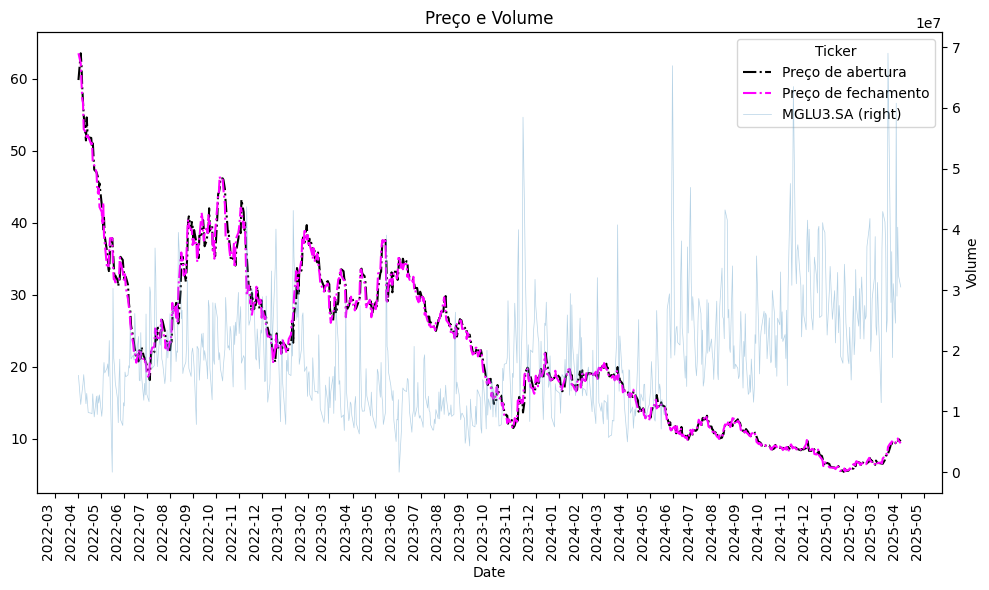

In [44]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o gráfico de linha para 'Adj Close'
df.plot(y=['Open', 'Close'], color=['black', 'magenta'], ls='-.', ax=ax, label=['Preço de abertura','Preço de fechamento'])

# Criar um segundo eixo y para 'Volume'
ax1 = df.plot(y='Volume', secondary_y=True, color='#6CA6CD', ax=ax, alpha=0.5, rot=0, lw=0.5)
ax1.set(ylabel='Volume')

# Definir o eixo y para 'Volume'
ax1.set_ylabel('Volume')

# Definir a escala do eixo x para exibir apenas os meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotacionar os rótulos do eixo x em 90 graus
ax.tick_params(axis='x', rotation=90)

plt.title('Preço e Volume')
plt.tight_layout()
plt.show()

Aqui temos uma série temporal real.

Cada ponto representa o preço da ação ao longo do tempo.



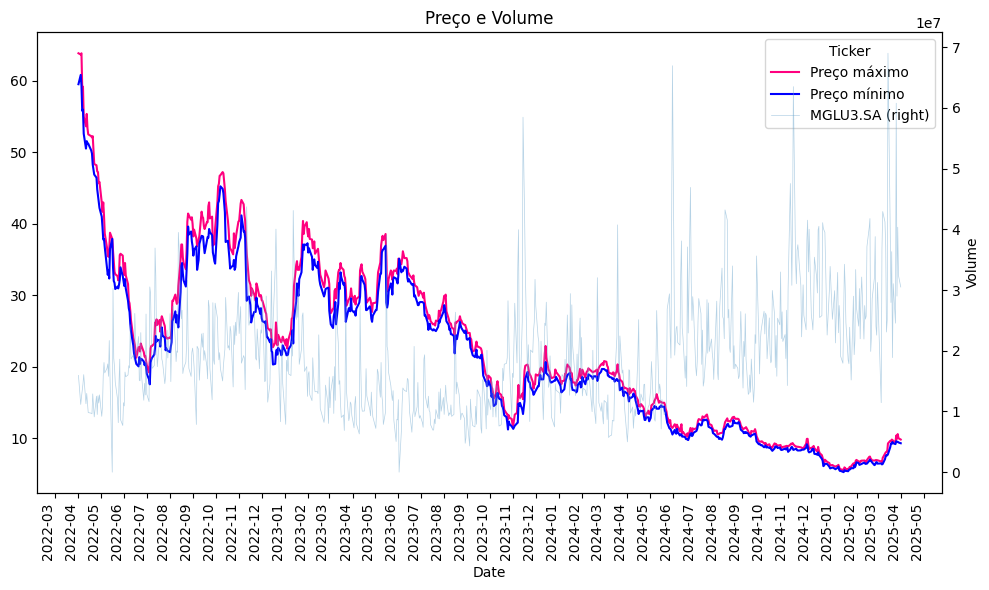

In [45]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o gráfico de linha para 'High' e 'Low'
df.plot(y=['High', 'Low'], color=['#FF007F', 'blue'], ax=ax, label=['Preço máximo', 'Preço mínimo'])

# Criar um segundo eixo y para 'Volume'
ax1 = df.plot(y='Volume', secondary_y=True, color='#6CA6CD', ax=ax, alpha=0.5, rot=0, lw=0.5)
ax1.set(ylabel='Volume')

# Definir o eixo y para 'Volume'
ax1.set_ylabel('Volume')

# Definir a escala do eixo x para exibir apenas os meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotacionar os rótulos do eixo x em 90 graus
ax.tick_params(axis='x', rotation=90)

plt.title('Preço e Volume')
plt.tight_layout()
plt.show()

# Visualização do preço médio

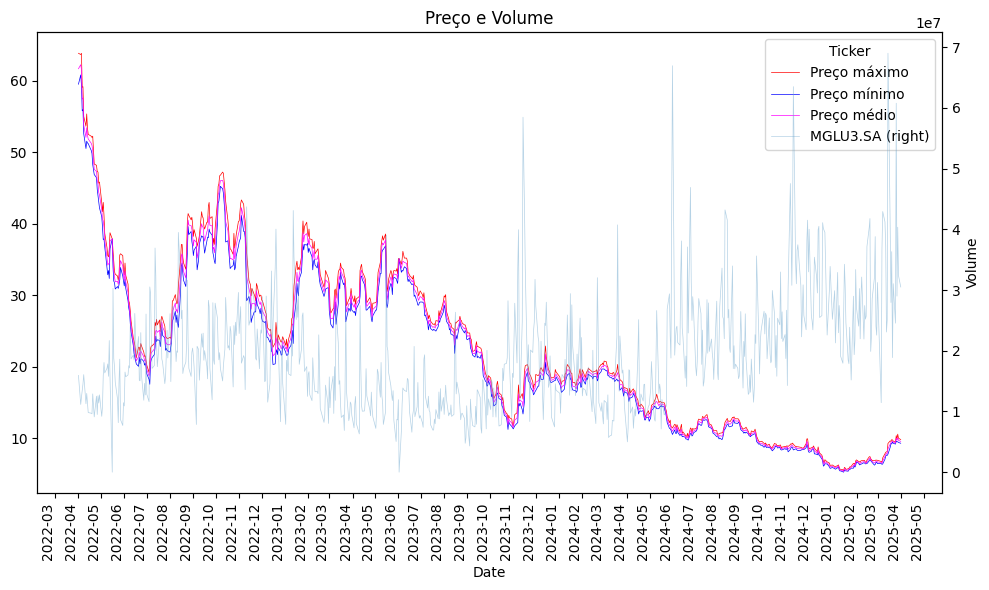

In [46]:
# Calcular o preço médio
df['Average'] = (df['High'] + df['Low']) / 2

# Plotar o gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o gráfico de linha para 'High', 'Low' e 'Average'
df.plot(y=['High', 'Low', 'Average'], color=['red', 'blue', 'magenta'], ax=ax,
        label=['Preço máximo', 'Preço mínimo', 'Preço médio'], linewidth=0.5)

# Criar um segundo eixo y para 'Volume'
ax1 = df.plot(y='Volume', secondary_y=True, color='#6CA6CD', ax=ax, alpha=0.5, rot=0, lw=0.5)
ax1.set(ylabel='Volume')

# Definir o eixo y para 'Volume'
ax1.set_ylabel('Volume')

# Definir a escala do eixo x para exibir apenas os meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotacionar os rótulos do eixo x em 90 graus
ax.tick_params(axis='x', rotation=90)

plt.title('Preço e Volume')
plt.tight_layout()
plt.show()

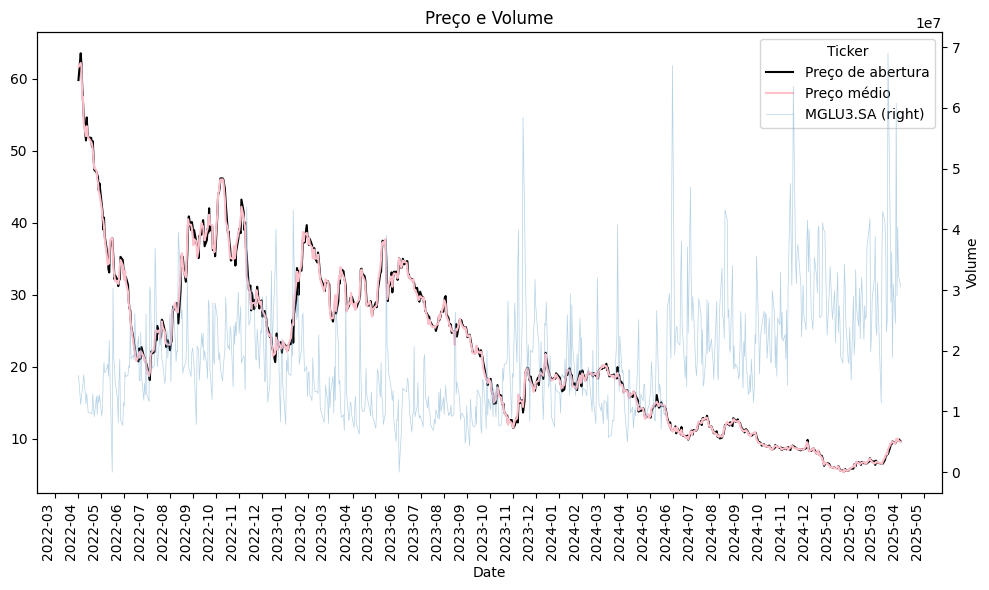

In [47]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o gráfico de linha para 'Adj Close'
df.plot(y=['Open','Average'], color=['black', 'pink'], ls='solid', ax=ax, label=['Preço de abertura','Preço médio'])

# Criar um segundo eixo y para 'Volume'
ax1 = df.plot(y='Volume', secondary_y=True, color='#6CA6CD', ax=ax, alpha=0.5, rot=0, lw=0.5)
ax1.set(ylabel='Volume')

# Definir o eixo y para 'Volume'
ax1.set_ylabel('Volume')

# Definir a escala do eixo x para exibir apenas os meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotacionar os rótulos do eixo x em 90 graus
ax.tick_params(axis='x', rotation=90)

plt.title('Preço e Volume')
plt.tight_layout()
plt.show()

**Decomposição de séries temporais**

Carregando as armas pesadas

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse
import statsmodels.api as sm

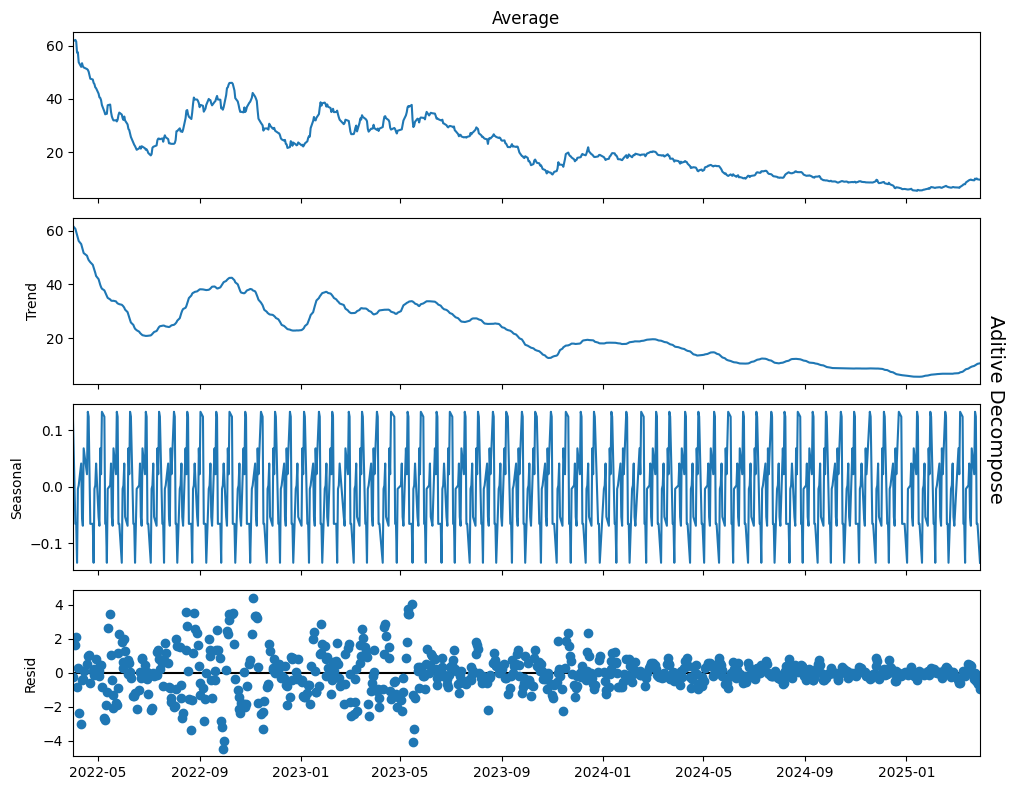

In [49]:
decomposition = sm.tsa.seasonal_decompose(df['Average'], model = 'aditive', period=12, extrapolate_trend=3, two_sided=True)
plt.rcParams.update({'figure.figsize': (10,8)})
decomposition.plot().suptitle('Aditive Decompose', fontsize=14, x=1, y=0.6, rotation=270)
plt.show()

**Observação 1:** O parâmetro two_sided na função seasonal_decompose do statsmodels controla se a decomposição sazonal é feita de forma "bidirecional" ou "unilateral".

Quando two_sided=True, a decomposição é feita em ambas as direções, permitindo que os efeitos sazonais sejam observados tanto antes quanto depois do ponto central. Isso pode ser útil quando os dados exibem sazonalidade simétrica.
Quando two_sided=False, a decomposição é feita de forma unilateral, considerando apenas os dados após o ponto central. Isso pode ser útil quando os dados exibem uma tendência clara e a sazonalidade é mais proeminente em uma direção.
A escolha entre two_sided=True e two_sided=False depende da natureza dos seus dados e do comportamento sazonal que você está tentando capturar na decomposição.

# Modelo Multiplicativo

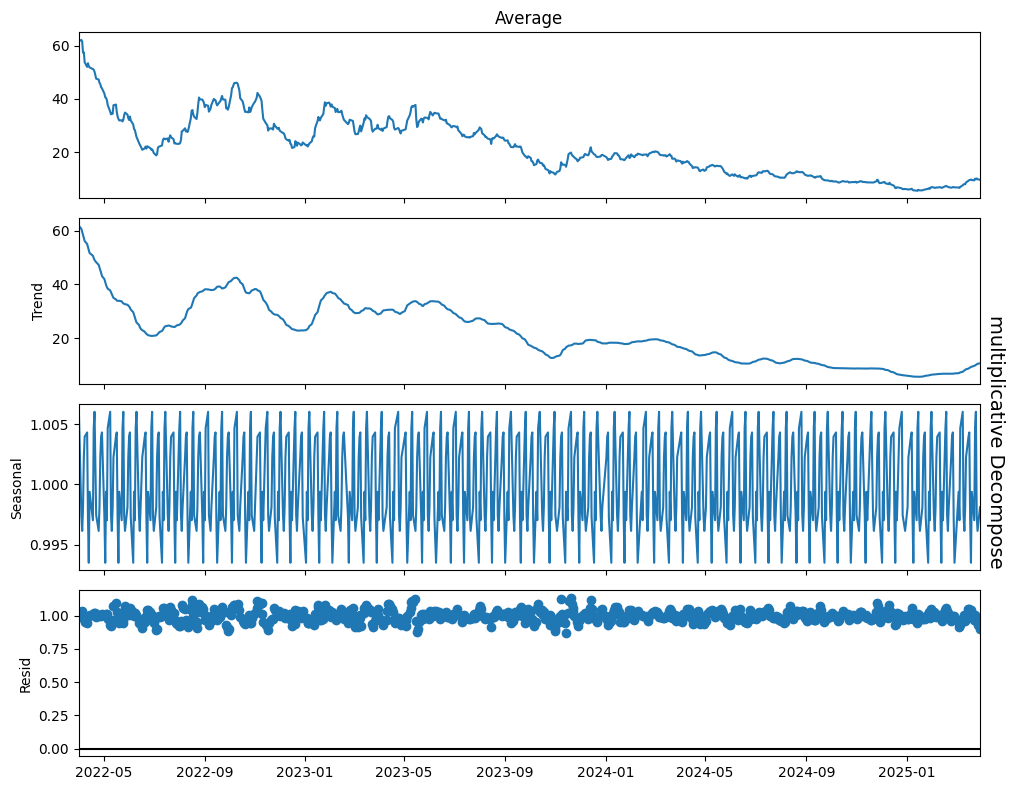

In [50]:
decomposition = sm.tsa.seasonal_decompose(df['Average'], model = 'multiplicative', period=12, extrapolate_trend=3, two_sided=True)
plt.rcParams.update({'figure.figsize': (10,8)})
decomposition.plot().suptitle('multiplicative Decompose', fontsize=14, x=1, y=0.6, rotation=270)
plt.show()

**Explicação sobre a linha preta dos resíduos:**

A linha preta contínua próxima de zero nos gráficos de resíduos representa a componente de tendência dos resíduos. Nos modelos de decomposição de séries temporais, após remover as componentes sazonal, de tendência e opcionalmente de ciclo, o que resta são os resíduos, que são a parte não explicada pelos componentes anteriores.

Idealmente, os resíduos deveriam ser estacionários e aleatórios, o que significa que não deve haver nenhuma tendência discernível neles. No entanto, em muitos casos reais, pode haver uma pequena tendência remanescente nos resíduos, o que é representado pela linha preta contínua próxima de zero nos gráficos de resíduos. Esta linha pode indicar que ainda há alguma informação não capturada pelo modelo ou que há algum padrão nos dados que não foi adequadamente modelado.

Se a linha preta contínua estiver longe de zero ou mostrar um padrão claro, isso pode indicar que o modelo não está capturando completamente a estrutura dos dados ou que há alguma fonte de erro sistemático que não está sendo considerada. Isso pode sugerir a necessidade de ajustes ou refinamentos no modelo.







# Visualização

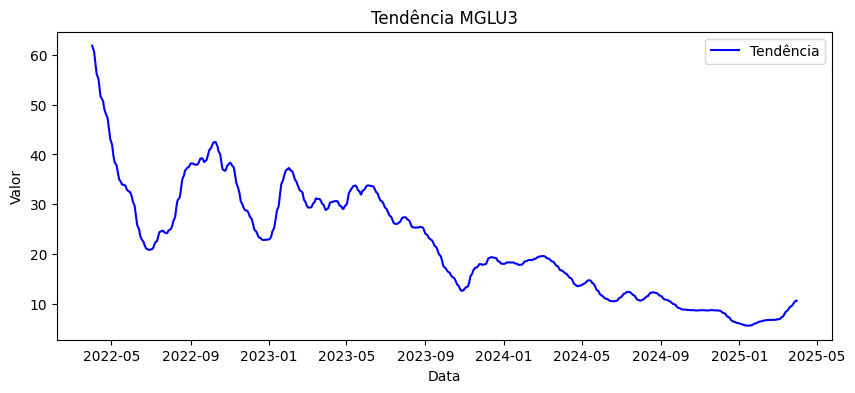

In [51]:
# plot
fig, ax = plt.subplots(figsize=(10, 4))

# Acessar valores da tendência extrapolada
trend = decomposition.trend.dropna()

# Plotar tendência extrapolada
plt.plot(trend.index, trend, color='blue', label='Tendência')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.title('Tendência MGLU3')
plt.legend()
plt.show()

# **Modelagem com o Prophet - previsão e detecção de "change points"**

In [52]:
# Criando uma nova coluna que copia o índice
df['Date'] = df.index

# Convertendo a coluna 'Date' para datetime
df['Date'] = pd.to_datetime(df['Date'], unit='s', format='%m%d%Y')

# Criando um novo dataframe com a coluna Date e coluna do preço médio da ação
new_df = df[['Date', 'Average']].reset_index(drop=True)

# Renomeando coluna "Date" para "ds" e coluna "Average" para "y"
new_df.rename(columns={'Date': 'ds', 'Average': 'y'}, inplace=True)

# Verificar o novo DataFrame
new_df.head()

Price,ds,y
Ticker,,
0,2022-04-01,61.658118
1,2022-04-04,62.220219
2,2022-04-05,61.571643
3,2022-04-06,57.420746
4,2022-04-07,57.550457


# Instalação dos Pacotes

In [53]:
!pip install numpy cython
!pip install pystan
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00


In [54]:
!pip install prophet --no-binary :all:

O argumentos:

- **interval_width**: Define a largura do intervalo de confiança para as previsões.

- **growth**: Especifica o tipo de crescimento do modelo. Pode ser 'linear' ou 'logistic'.

- **seasonality_mode**: Define o modo de sazonalidade. Pode ser 'additive' ou 'multiplicative'.

- **changepoint_range**: Define a porcentagem dos dados que é usada para encontrar pontos de mudança na tendência.

- **changepoint_prior_scale**: Define a escala do parâmetro de mudança de tendência. Valores maiores permitem mais pontos de mudança.

- **daily_seasonality**: Se verdadeiro, ativa a sazonalidade diária no modelo.

Para mais informações: https://facebook.github.io/prophet/docs/trend_changepoints.html

**Importante**!

Por padrão, os changepoints são inferidos apenas para os primeiros 80% da série temporal para ter bastante espaço para projetar a tendência para frente e evitar o ajuste excessivo das flutuações no final da série temporal. Este padrão funciona em muitas situações, mas não em todas, e pode ser alterado usando o argumento changepoint_range. Por exemplo, m = Prophet(changepoint_range=0.9) em Python ou m <- prophet(changepoint.range = 0.9) em R colocará changepoints potenciais nos primeiros 90% da série temporal.

Outro argumento importante é o changepoint_prior_scale. Esse argumento controla a flexibilidade do modelo em ajustar os changepoints. Valores menores desse parâmetro tornam o modelo mais rígido, ou seja, menos propenso a ajustar mudanças na tendência. Por outro lado, valores maiores tornam o modelo mais flexível, permitindo mais mudanças na tendência. Um valor de 1 é o padrão, mas pode ser ajustado conforme necessário para melhorar o ajuste do modelo aos dados.

In [55]:
from prophet import Prophet
# Make the prophet model and fit on the df
model = Prophet(interval_width=0.95, growth='linear', seasonality_mode='additive', changepoint_range=1, changepoint_prior_scale=1, daily_seasonality=True)
model.fit(new_df)

In [56]:
# Make a future dataframe for 30 days
future = model.make_future_dataframe(periods=30, freq='D')
print(future)

            ds
0   2022-04-01
1   2022-04-04
2   2022-04-05
3   2022-04-06
4   2022-04-07
..         ...
773 2025-04-26
774 2025-04-27
775 2025-04-28
776 2025-04-29
777 2025-04-30

[778 rows x 1 columns]


In [57]:
# Make predictions
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2022-04-01,61.275068,58.380846,64.022805
1,2022-04-04,59.431695,56.395793,62.290842
2,2022-04-05,58.744046,55.802047,61.793597
3,2022-04-06,57.968777,55.177382,60.993109
4,2022-04-07,57.329970,54.481299,60.307257


- ds: data da previsão
- yhat: o valor previsto da nossa métrica (em Estatísticas, yhat é uma notação - tradicionalmente usada para representar os valores previstos de um valor y)
- yhat_lower: o limite inferior da previsão
- yhat_upper: o limite superior da previsão

In [58]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(27)

,ds,yhat,yhat_lower,yhat_upper
751,2025-04-04,10.165900,7.242812,13.107244
752,2025-04-05,8.125574,5.078269,11.047714
753,2025-04-06,8.153840,5.222089,11.183671
754,2025-04-07,10.398490,7.356531,13.564294
755,2025-04-08,10.406728,7.272676,13.348510
756,2025-04-09,10.329804,7.282334,13.431228
757,2025-04-10,10.392075,7.274795,13.778044
758,2025-04-11,10.338910,7.322117,13.890618
759,2025-04-12,8.289918,4.741846,11.676948
760,2025-04-13,8.315867,4.874993,11.712515


Visualizando modelo e sazonalidade

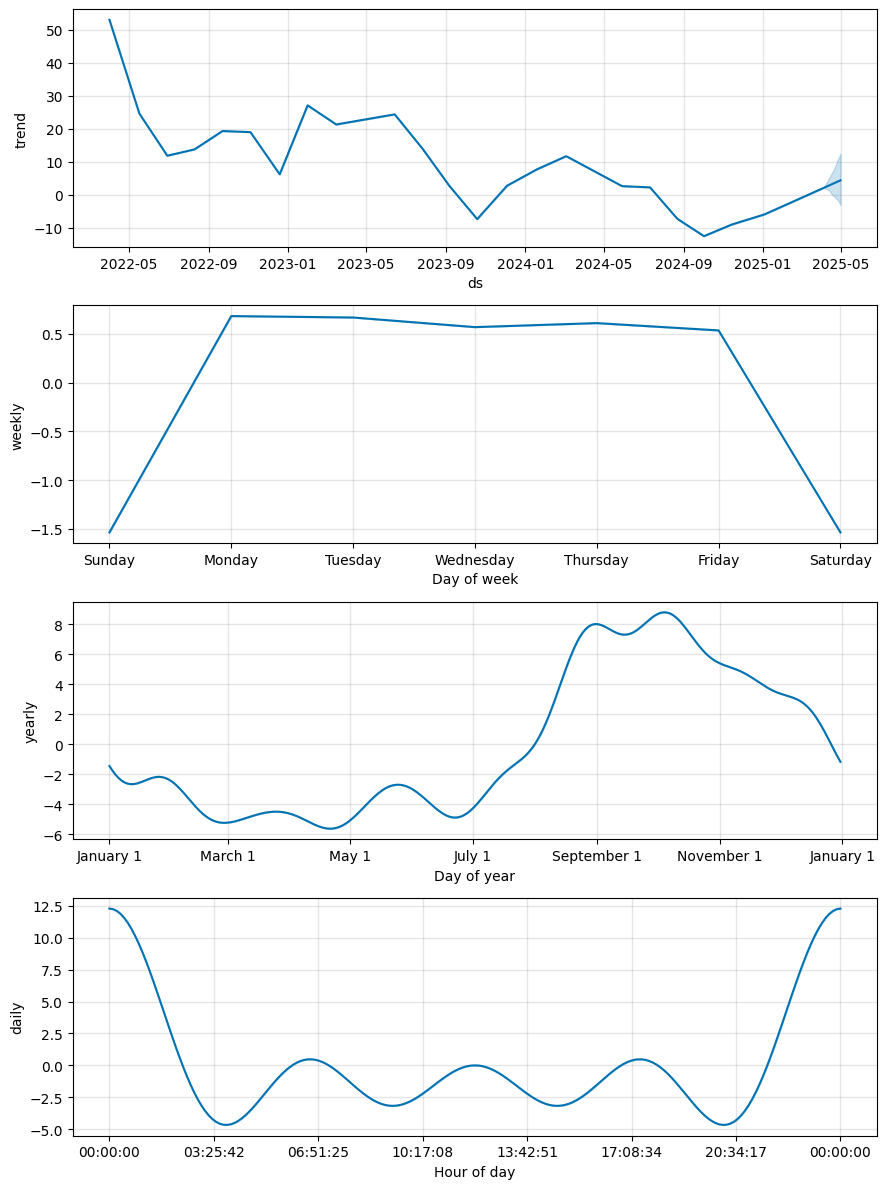

In [59]:
fig1 = model.plot_components(forecast)

**O que é o eixo Y nesses gráficos do Prophet?**
- Não é o valor do ativo (preço)
- É o efeito da componente sobre o valor final

y(t) = tendência + sazonalidade + erro

Isso demonstra o quanto a sazonalidade influência no valor das obeservações.

Ex: segunda mais otimista, sexta mais conservadora.



**E a diária?**
- Nossos dados são diários?

Correção: Prophet(
    daily_seasonality=False,
    weekly_seasonality=True
)

Visualizando o modelo, previsão e observações

---



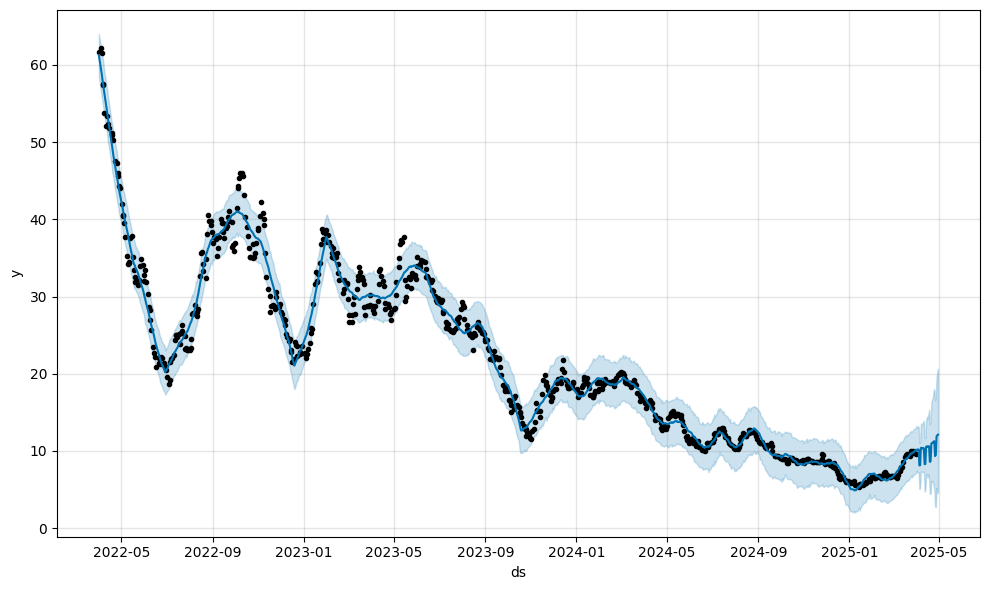

In [61]:
model.plot(forecast, uncertainty=True);

Detecção de change point

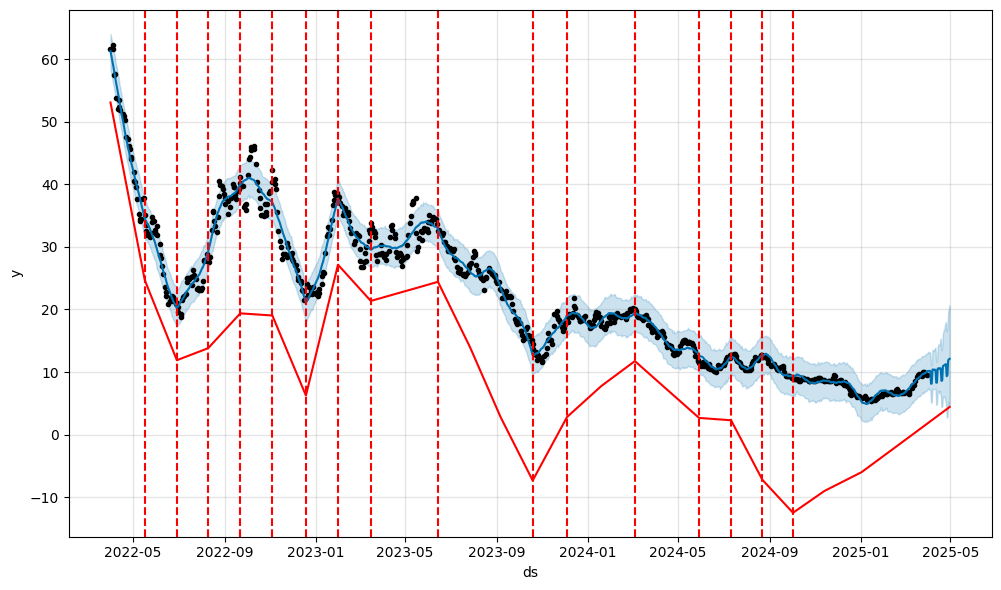

In [62]:
from prophet.plot import add_changepoints_to_plot
fig = model.plot(forecast, uncertainty=True);
a = add_changepoints_to_plot(fig.gca(), model, forecast, threshold = 1);

**Importante!**

Diferente de modelos autorregressivos, o Prophet modela explicitamente a tendência como uma função que pode mudar ao longo do tempo.

E ai está o diferencial!



*   Média móveel "filtra a tendencia - via vizinhos, valores próximos
*   ARIMA captura padrões - via autocorrelação - indireto (lags, diferenciação)
*   Prophet modela tendência - explicitamente com changepoints - direto (quebra de tendência)



